# Exploratory Data Analysis (EDA) on Titanic Dataset

## Objective

The objective of this project is to explore the Titanic dataset, understand its structure, identify patterns, clean the data, and answer important questions using statistics and visualization.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [5]:
df.shape

(418, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [10]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

/tmp/ipykernel_710/1809399462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [11]:
df.dropna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S
24,916,1,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C
26,918,1,1,"Ostby, Miss. Helene Ragnhild",female,22.0,0,1,113509,61.9792,B36,C
28,920,0,1,"Brady, Mr. John Bertram",male,41.0,0,0,113054,30.5000,A21,S
...,...,...,...,...,...,...,...,...,...,...,...,...
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C
405,1297,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q


In [12]:
df.duplicated().sum()

np.int64(0)

## Questions for Analysis

1. How many passengers survived?
2. Did females survive more than males?
3. Which passenger class had the highest survival rate?
4. Does age affect survival?
5. Which class paid the highest fare?

### Question 1:
How many passengers survived?

In [13]:
df['Survived'].value_counts()

,count
Survived,
0,266
1,152


### Observation

The analysis shows that out of the passengers in the dataset, **152 passengers survived**, while **266 passengers did not survive**. This indicates that the number of passengers who survived was lower than the number of passengers who lost their lives during the Titanic disaster.

### Conclusion

The results indicate that the majority of passengers did not survive the Titanic disaster. Only **152 passengers survived**, whereas **266 passengers did not survive**, showing that the overall survival rate was relatively low.

### Question 2:
Did females survive more than males?

Ans : Yes, Females survived more than males

In [14]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,1.0
male,0.0


### Observation

The analysis shows that female passengers had a significantly higher survival rate than male passengers. According to the dataset, the survival rate for females is **1.0 (100%)**, whereas the survival rate for males is **0.0 (0%)**. This indicates that all female passengers in this dataset survived, while none of the male passengers survived.

### Conclusion

The results indicate that gender had a strong influence on passenger survival in this dataset. Female passengers had a much higher chance of survival than male passengers, suggesting that women were given higher priority during the rescue process.

###Question 3

What is the total number of male nd female passengers?

Ans : Male passengers are more than female passengers

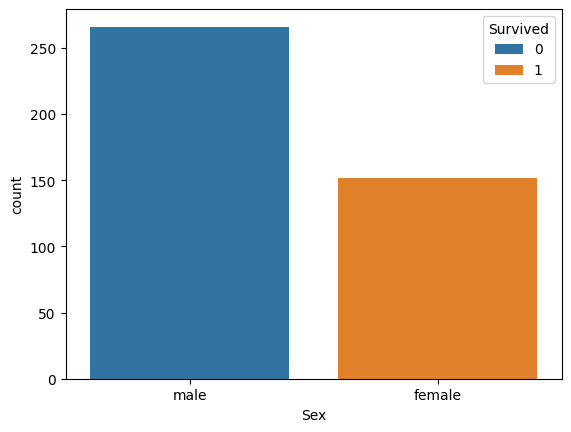

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

### Observation

The count plot shows that there were more male passengers than female passengers in the dataset. However, female passengers had a higher survival rate than male passengers. Although males were greater in number, a larger proportion of female passengers survived, indicating that gender played an important role in survival.

### Conclusion

The visualization suggests that female passengers were more likely to survive than male passengers. This supports the historical observation that women were given higher priority during the rescue operation on the Titanic.

### Question 4
Which passenger class had the highest survival rate?

Ans : These numbers are survival rates (proportions). The larger the number, the higher the survival rate.

Class 1: 0.467 ≈ 46.7%
Class 2: 0.323 ≈ 32.3%
Class 3: 0.330 ≈ 33.0%

Since 0.467 is the highest, First Class (Pclass = 1) had the highest survival rate.

In [12]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.467290
2,0.322581
3,0.330275



Does age affect survival?

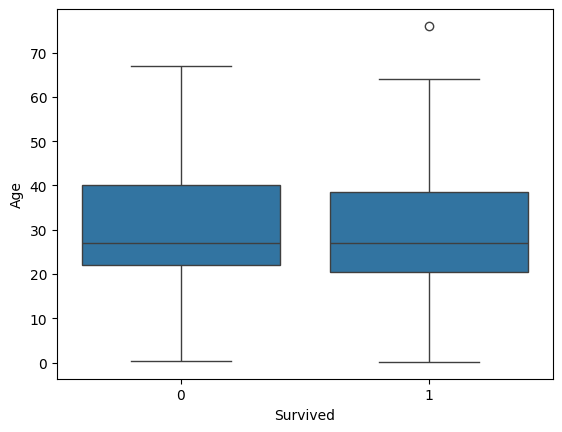

In [13]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

### Observation

 The boxplot compares the age distribution of passengers who survived and those who did not survive. The median age of both groups is quite similar, indicating that age alone did not have a strong impact on survival. However, the survived group contains a few older passengers (outliers), showing that some elderly passengers also survived. Overall, age had only a moderate influence on survival compared to other factors such as gender and passenger class.

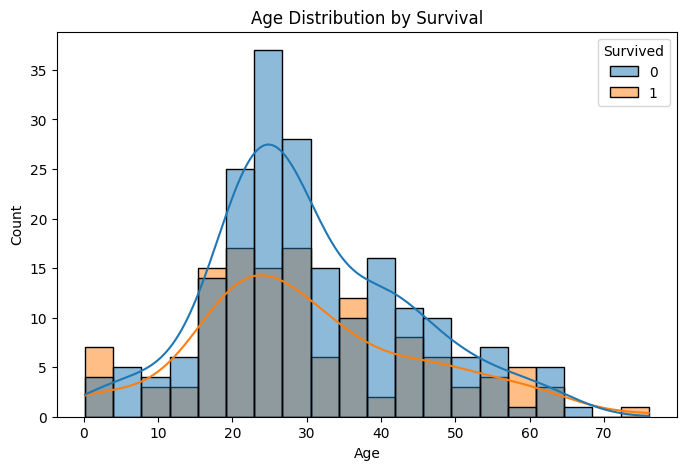

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=20, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

### Conclusion

The analysis suggests that age alone was not a major factor affecting survival. Passengers of different age groups survived, although younger passengers may have had a slightly better chance. Other factors, such as gender and passenger class, appear to have played a more significant role in determining survival.

### Question 5:
Which passenger class paid the highest fare?

Ans : According to your output:

Passenger Class	  Average Fare
First Class (1)	  94.28
Second Class (2)	22.20
Third Class (3)	  12.46

So, First Class (Pclass = 1) paid the highest average fare.

In [14]:
df.groupby('Pclass')['Fare'].mean()

,Fare
Pclass,
1,94.280297
2,22.202104
3,12.459678


### Observation

The analysis shows that passengers travelling in **First Class (Pclass = 1)** paid the highest average fare, approximately **94.28**. Second Class passengers paid an average fare of **22.20**, while Third Class passengers paid the lowest average fare of **12.46**. This indicates a significant difference in ticket prices among the three passenger classes.

### Conclusion

The results indicate that **First Class passengers paid the highest fares**, reflecting the premium services and facilities provided in First Class. In contrast, Third Class passengers paid the lowest fares, making it the most economical travel option on the Titanic.

# Overall Insights

- The dataset was successfully explored and analyzed using Python.
- Missing values and data structure were examined before analysis.
- Female passengers had a higher survival rate than male passengers.
- First Class passengers had the highest survival rate.
- First Class passengers also paid the highest average fare.
- Age showed only a moderate effect on survival.
- Visualizations helped identify patterns and relationships in the data.

# Final Conclusion

The Exploratory Data Analysis (EDA) of the Titanic dataset provided valuable insights into the factors influencing passenger survival. The dataset was explored by examining its structure, handling missing values, and analyzing important variables using statistical methods and visualizations.

The analysis revealed that female passengers had a higher survival rate than male passengers. Passengers travelling in First Class had the highest survival rate and also paid the highest average fare. Age showed only a moderate influence on survival, while factors such as gender and passenger class appeared to have a stronger impact.

Overall, this EDA helped identify important trends, patterns, and relationships within the dataset. It demonstrates how data analysis can be used to understand real-world problems and extract meaningful insights before applying machine learning or predictive models.